# CF attribute analysis
- Load the calculated attributes from C2's input data
- C2_DATA doesnt have the cf information so we need to use the fold data
- Analyse how they are distributed in correct vs incorrect predictions

> We are workign in the new split - cross fold validation on the C0 held out set

In [43]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

In [120]:
# Load c2 data
cf16_fold0_data = pd.read_csv("/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/fold_0_predictions.csv")
cf16_fold1_data = pd.read_csv("/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/fold_1_predictions.csv")
cf16_fold2_data = pd.read_csv("/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/fold_2_predictions.csv")
cf16_fold3_data = pd.read_csv("/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/fold_3_predictions.csv")
cf16_fold4_data = pd.read_csv("/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/fold_4_predictions.csv")


In [121]:
# Pool the folds together
cf16_merged_data = pd.concat([cf16_fold0_data, cf16_fold1_data, cf16_fold2_data, cf16_fold3_data, cf16_fold4_data], ignore_index=True)

In [122]:
cf16_merged_data

,path,effusion_prob,effusion_true,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,MLP_B2_prob,MLP_B3_prob,MLP_B4_prob,MLP_B5_prob,MLP_M1_prob,MLP_M2_prob,MLP_M3_prob,MLP_M4_prob,MLP_M5_prob,MLP_M6_prob
0,CheXpert-v1.0-small/train/patient00008/study1/...,0.989891,1.0,-0.001258,-0.002981,0.004603,0.001782,0.038358,0.399419,-0.001282,...,0.911461,0.993021,0.937656,0.988203,0.990234,1.000000,1.000000,1.000000,1.000000,1.000000
1,CheXpert-v1.0-small/train/patient00008/study2/...,0.803473,1.0,-0.001191,-0.002815,0.002819,0.001348,0.057667,0.703849,-0.001344,...,0.931416,0.990229,0.932353,0.998319,0.980807,0.999987,0.991720,0.999688,0.999998,0.996500
2,CheXpert-v1.0-small/train/patient00010/study1/...,0.022443,0.0,-0.001185,-0.000544,0.002301,0.005169,-0.117937,-0.033050,-0.001290,...,0.977377,0.971201,0.970851,0.976558,0.732228,0.999998,0.999998,0.999905,1.000000,0.999991
3,CheXpert-v1.0-small/train/patient00012/study2/...,0.061503,0.0,-0.001186,-0.001272,0.003885,0.003653,-0.103996,0.122837,-0.001299,...,0.923050,0.898308,0.916926,0.855302,0.945142,0.999998,0.999970,0.999894,1.000000,0.999952
4,CheXpert-v1.0-small/train/patient00012/study1/...,0.029165,0.0,-0.001169,-0.001557,0.002562,0.004091,-0.134545,0.211838,-0.001316,...,0.947813,0.936584,0.955979,0.950232,0.921419,0.999195,0.999350,0.943226,1.000000,0.999999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45150,CheXpert-v1.0-small/train/patient47326/study15...,0.991323,1.0,-0.001218,-0.002772,0.004868,0.001912,0.038572,0.362541,-0.001303,...,0.998907,0.997212,0.996451,0.987423,0.999984,1.000000,1.000000,0.999999,1.000000,0.999998
45151,CheXpert-v1.0-small/train/patient47326/study16...,0.997699,1.0,-0.001202,-0.003193,0.004110,0.002293,0.003134,0.662992,-0.001271,...,0.998319,0.982271,0.995493,0.998189,0.976578,0.999999,1.000000,0.998086,1.000000,0.999996
45152,CheXpert-v1.0-small/train/patient47326/study6/...,0.994333,1.0,-0.001193,-0.002723,0.003124,0.002845,0.046595,0.291322,-0.001343,...,0.997847,0.988820,0.990001,0.987734,0.997939,1.000000,1.000000,0.999824,1.000000,1.000000
45153,CheXpert-v1.0-small/train/patient47326/study14...,0.991939,1.0,-0.001210,-0.003301,0.006024,0.002212,0.097969,0.434269,-0.001248,...,0.996209,0.977627,0.988378,0.994271,0.990344,1.000000,1.000000,0.999989,1.000000,0.999997


In [141]:
# Check columns
for column in cf16_merged_data.columns:
    print(column)

path
effusion_prob
effusion_true
emb_0
emb_1
emb_2
emb_3
emb_4
emb_5
emb_6
emb_7
emb_8
emb_9
emb_10
emb_11
emb_12
emb_13
emb_14
emb_15
emb_16
emb_17
emb_18
emb_19
emb_20
emb_21
emb_22
emb_23
emb_24
emb_25
emb_26
emb_27
emb_28
emb_29
emb_30
emb_31
emb_32
emb_33
emb_34
emb_35
emb_36
emb_37
emb_38
emb_39
emb_40
emb_41
emb_42
emb_43
emb_44
emb_45
emb_46
emb_47
emb_48
emb_49
emb_50
emb_51
emb_52
emb_53
emb_54
emb_55
emb_56
emb_57
emb_58
emb_59
emb_60
emb_61
emb_62
emb_63
emb_64
emb_65
emb_66
emb_67
emb_68
emb_69
emb_70
emb_71
emb_72
emb_73
emb_74
emb_75
emb_76
emb_77
emb_78
emb_79
emb_80
emb_81
emb_82
emb_83
emb_84
emb_85
emb_86
emb_87
emb_88
emb_89
emb_90
emb_91
emb_92
emb_93
emb_94
emb_95
emb_96
emb_97
emb_98
emb_99
emb_100
emb_101
emb_102
emb_103
emb_104
emb_105
emb_106
emb_107
emb_108
emb_109
emb_110
emb_111
emb_112
emb_113
emb_114
emb_115
emb_116
emb_117
emb_118
emb_119
emb_120
emb_121
emb_122
emb_123
emb_124
emb_125
emb_126
emb_127
emb_128
emb_129
emb_130
emb_131
emb_132
emb_133
emb_1

In [140]:
DISEASE = 'effusion'

META_COLS = {
    f'{DISEASE}_prob', f'{DISEASE}_pred', f'{DISEASE}_true',
    'correct', 'path', 'patient_id', 'cf_prob', 'cf_paths', 'margin'
}

ORGANS = [
    "Left Lung", "Right Lung", "Heart", "Mediastinum",
    "Facies Diaphragmatica", "Aorta", "Left Hilus Pulmonis",
    "Right Hilus Pulmonis", "Left Scapula", "Right Scapula",
    "Left Clavicle", "Right Clavicle", "Weasand", "Spine"
]

FEATURE_TYPES = {
    'shape2D': ['shape2D'],
    'firstorder': ['firstorder'],
    'geometric': ['area_pixels', 'bbox', 'perimeter']
}

def build_categories(columns):

    categories = {}

    for col in columns:

        # label metadata columns but DO NOT skip them
        if col in META_COLS:
            prefix = 'META'
        else:
            prefix = 'Delta' if col.startswith('delta_') else 'Original'

        # find organ
        organ = next((o for o in ORGANS if o in col), 'Global')

        # find feature type
        feature_type = 'other'

        for ftype, keywords in FEATURE_TYPES.items():
            if any(k in col for k in keywords):
                feature_type = ftype
                break

        # build category name
        category = f"{prefix} | {organ} | {feature_type}"

        categories.setdefault(category, []).append(col)

    return categories


# build categories
feature_cols = [
    c for c in cf16_merged_data.columns
    if c not in META_COLS
]

categories = build_categories(feature_cols)
categories


{'Original | Global | other': ['emb_0',
  'emb_1',
  'emb_2',
  'emb_3',
  'emb_4',
  'emb_5',
  'emb_6',
  'emb_7',
  'emb_8',
  'emb_9',
  'emb_10',
  'emb_11',
  'emb_12',
  'emb_13',
  'emb_14',
  'emb_15',
  'emb_16',
  'emb_17',
  'emb_18',
  'emb_19',
  'emb_20',
  'emb_21',
  'emb_22',
  'emb_23',
  'emb_24',
  'emb_25',
  'emb_26',
  'emb_27',
  'emb_28',
  'emb_29',
  'emb_30',
  'emb_31',
  'emb_32',
  'emb_33',
  'emb_34',
  'emb_35',
  'emb_36',
  'emb_37',
  'emb_38',
  'emb_39',
  'emb_40',
  'emb_41',
  'emb_42',
  'emb_43',
  'emb_44',
  'emb_45',
  'emb_46',
  'emb_47',
  'emb_48',
  'emb_49',
  'emb_50',
  'emb_51',
  'emb_52',
  'emb_53',
  'emb_54',
  'emb_55',
  'emb_56',
  'emb_57',
  'emb_58',
  'emb_59',
  'emb_60',
  'emb_61',
  'emb_62',
  'emb_63',
  'emb_64',
  'emb_65',
  'emb_66',
  'emb_67',
  'emb_68',
  'emb_69',
  'emb_70',
  'emb_71',
  'emb_72',
  'emb_73',
  'emb_74',
  'emb_75',
  'emb_76',
  'emb_77',
  'emb_78',
  'emb_79',
  'emb_80',
  'emb_81

## Statistical analysis

In [142]:
total_features = sum(len(cols) for cols in categories.values())
print(f"Total features: {total_features}")
print(f"Total categories: {len(categories)}")
for cat, cols in categories.items():
    print(f"  {cat}: {len(cols)} features")

Total features: 1980
Total categories: 86
  Original | Global | other: 1070 features
  Original | Left Clavicle | geometric: 5 features
  Original | Left Clavicle | shape2D: 9 features
  Original | Left Clavicle | firstorder: 18 features
  Original | Left Scapula | geometric: 5 features
  Original | Left Scapula | shape2D: 9 features
  Original | Left Scapula | firstorder: 18 features
  Original | Right Scapula | geometric: 5 features
  Original | Right Scapula | shape2D: 9 features
  Original | Right Scapula | firstorder: 18 features
  Original | Left Lung | geometric: 5 features
  Original | Left Lung | shape2D: 9 features
  Original | Left Lung | firstorder: 18 features
  Original | Right Lung | geometric: 5 features
  Original | Right Lung | shape2D: 9 features
  Original | Right Lung | firstorder: 18 features
  Original | Left Hilus Pulmonis | geometric: 5 features
  Original | Left Hilus Pulmonis | shape2D: 9 features
  Original | Left Hilus Pulmonis | firstorder: 18 features
  O

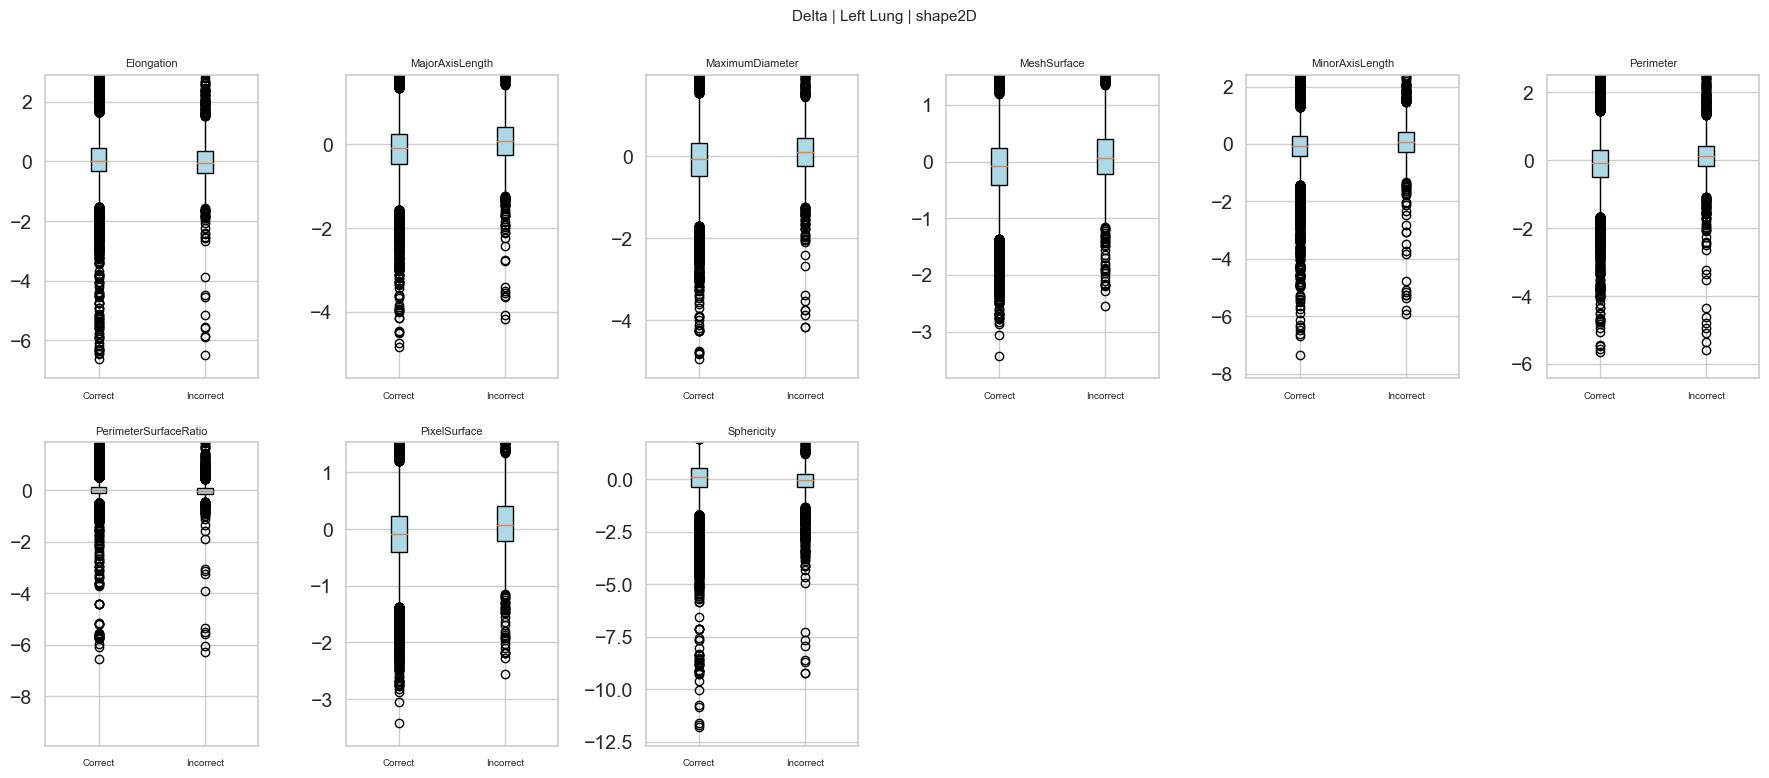

In [143]:
def plot_category(df, category_name, feature_cols, correct_col='correct', max_cols=6):
    """
    Boxplot of all features in a category, split by correct vs incorrect.
    Wraps into multiple rows if there are more than max_cols features.
    """
    
    if len(feature_cols) > 50:
        print(f"Skipping {category_name} — too many features ({len(feature_cols)})")
        return
    
    n_features = len(feature_cols)
    n_cols = min(n_features, max_cols)
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 4 * n_rows))
    
    # Always make axes a flat array for easy indexing
    axes = np.array(axes).flatten()
    
    correct_mask   = df[correct_col] == 1
    incorrect_mask = df[correct_col] == 0
    
    for i, col in enumerate(feature_cols):
        ax = axes[i]
        
        data_correct   = df.loc[correct_mask,   col].dropna().values
        data_incorrect = df.loc[incorrect_mask, col].dropna().values
        
        ax.boxplot(
            [data_correct, data_incorrect],
            labels=['Correct', 'Incorrect'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
        )
        
        # Clip y-axis at 99th percentile
        p99 = np.nanpercentile(np.concatenate([data_correct, data_incorrect]), 99)
        ax.set_ylim(bottom=None, top=p99 * 1.1)
        
        short_name = col.split('_')[-1]
        ax.set_title(short_name, fontsize=8)
        ax.tick_params(axis='x', labelsize=7)
    
    # Hide any unused subplots (when n_features doesn't fill the grid)
    for j in range(n_features, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(category_name, fontsize=11)
    plt.tight_layout()
    plt.show()
    
# Example: plot one 
example_category = "Delta | Left Lung | shape2D"
plot_category(cf16_merged_data, example_category, categories[example_category])

In [144]:
# Create a subdf that only has the delta features
delta_cols = [col for col in cf16_merged_data.columns if col.startswith('delta_')]
delta_df = cf16_merged_data[delta_cols + ['correct']]


# LDA - Linear Discriminant Analysis
LDA works by finding directions in the feature space that best separate the classes. It does this by maximizing the difference between the class means while minimizing the spread within each class.



In [145]:
# Import necessary libraries for LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [146]:
# Apply LDA to the delta features
X = delta_df.drop(columns=['correct']).values
y = delta_df['correct'].values
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)

In [147]:
# Print explained variance ratio
print("Explained variance ratio:", lda.explained_variance_ratio_)

Explained variance ratio: [1.]


In [148]:
# Print the most important features (those with the highest absolute coefficients in the LDA projection)
feature_importance = np.abs(lda.coef_[0])
feature_names = delta_df.drop(columns=['correct']).columns
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(20)

,feature,importance
192,delta_Left Hilus Pulmonis_original_firstorder_...,194.720932
83,delta_Right Scapula_original_shape2D_PixelSurface,157.944658
79,delta_Right Scapula_original_shape2D_MeshSurface,157.660062
211,delta_Heart_original_shape2D_PixelSurface,150.118568
335,delta_Spine_original_shape2D_MeshSurface,149.452746
339,delta_Spine_original_shape2D_PixelSurface,146.404146
207,delta_Heart_original_shape2D_MeshSurface,142.538631
179,delta_Left Hilus Pulmonis_original_shape2D_Pix...,134.928852
191,delta_Left Hilus Pulmonis_original_firstorder_...,128.055467
175,delta_Left Hilus Pulmonis_original_shape2D_Mes...,126.109967


In [149]:
# Add a column for category
feature_importance_df['category'] = feature_importance_df['feature'].apply(
    lambda f: next((cat for cat, cols in categories.items() if f in cols), 'other'))

In [150]:
feature_importance_df.head(20)

,feature,importance,category
192,delta_Left Hilus Pulmonis_original_firstorder_...,194.720932,Delta | Left Hilus Pulmonis | firstorder
83,delta_Right Scapula_original_shape2D_PixelSurface,157.944658,Delta | Right Scapula | shape2D
79,delta_Right Scapula_original_shape2D_MeshSurface,157.660062,Delta | Right Scapula | shape2D
211,delta_Heart_original_shape2D_PixelSurface,150.118568,Delta | Heart | shape2D
335,delta_Spine_original_shape2D_MeshSurface,149.452746,Delta | Spine | shape2D
339,delta_Spine_original_shape2D_PixelSurface,146.404146,Delta | Spine | shape2D
207,delta_Heart_original_shape2D_MeshSurface,142.538631,Delta | Heart | shape2D
179,delta_Left Hilus Pulmonis_original_shape2D_Pix...,134.928852,Delta | Left Hilus Pulmonis | shape2D
191,delta_Left Hilus Pulmonis_original_firstorder_...,128.055467,Delta | Left Hilus Pulmonis | firstorder
175,delta_Left Hilus Pulmonis_original_shape2D_Mes...,126.109967,Delta | Left Hilus Pulmonis | shape2D


In [154]:
feature_importance_df

(462, 3)


,feature,importance,category
192,delta_Left Hilus Pulmonis_original_firstorder_...,194.720932,Delta | Left Hilus Pulmonis | firstorder
83,delta_Right Scapula_original_shape2D_PixelSurface,157.944658,Delta | Right Scapula | shape2D
79,delta_Right Scapula_original_shape2D_MeshSurface,157.660062,Delta | Right Scapula | shape2D
211,delta_Heart_original_shape2D_PixelSurface,150.118568,Delta | Heart | shape2D
335,delta_Spine_original_shape2D_MeshSurface,149.452746,Delta | Spine | shape2D
...,...,...,...
107,delta_Left Lung_perimeter,0.001221,Delta | Left Lung | geometric
436,delta_Aorta_original_shape2D_Sphericity,0.001168,Delta | Aorta | shape2D
356,delta_Spine_original_firstorder_TotalEnergy,0.001034,Delta | Spine | firstorder
343,delta_Spine_original_firstorder_Energy,0.001034,Delta | Spine | firstorder


In [155]:
#. print the importances of the delta features grouped by category
category_importance = feature_importance_df.groupby('category')['importance'].sum().sort_values(ascending=False)
print(category_importance)  

category
Delta | Left Hilus Pulmonis | firstorder      434.860463
Delta | Right Scapula | shape2D               315.972728
Delta | Spine | shape2D                       296.836696
Delta | Heart | shape2D                       293.515887
Delta | Left Hilus Pulmonis | shape2D         262.000313
Delta | Left Scapula | shape2D                235.290910
Delta | Left Lung | shape2D                   229.618910
Delta | Right Hilus Pulmonis | firstorder     198.654709
Delta | Mediastinum | shape2D                 144.776111
Delta | Weasand | shape2D                     112.230862
Delta | Left Clavicle | shape2D                88.988736
Delta | Facies Diaphragmatica | shape2D        84.875692
Delta | Aorta | shape2D                        75.632347
Delta | Aorta | firstorder                     58.741399
Delta | Mediastinum | firstorder               55.407248
Delta | Weasand | firstorder                   51.312258
Delta | Right Scapula | firstorder             44.530590
Delta | Left Clavicle 

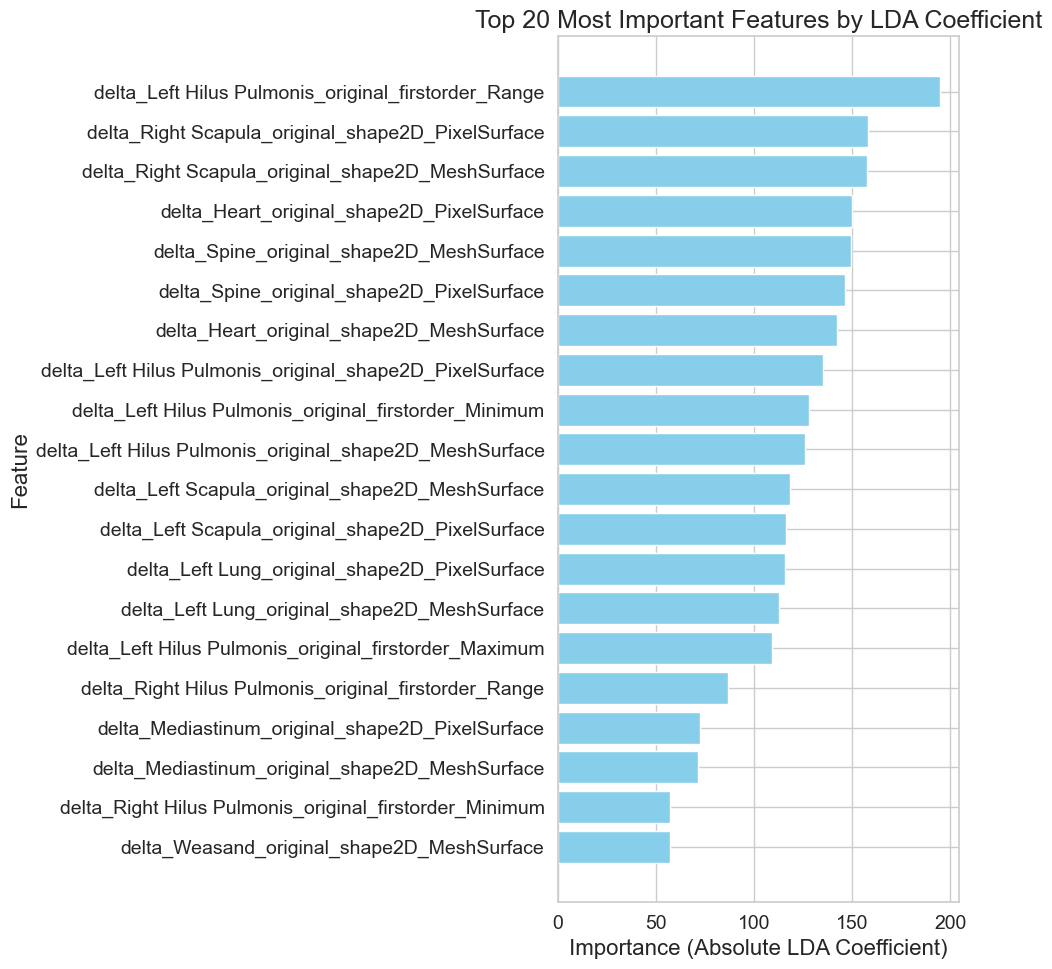

In [152]:
top_features = (
    feature_importance_df
    .sort_values('importance', ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 10))

plt.barh(
    top_features['feature'][::-1],
    top_features['importance'][::-1],
    color='skyblue'
)

plt.title('Top 20 Most Important Features by LDA Coefficient')
plt.xlabel('Importance (Absolute LDA Coefficient)')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()


Feature: delta_Left Hilus Pulmonis_original_firstorder_Range


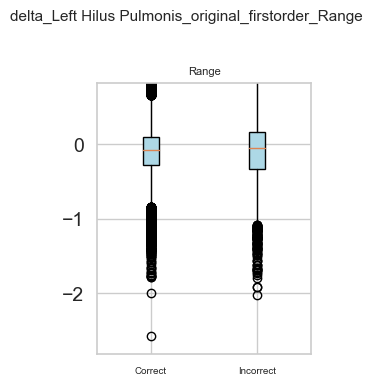


Feature: delta_Right Scapula_original_shape2D_PixelSurface


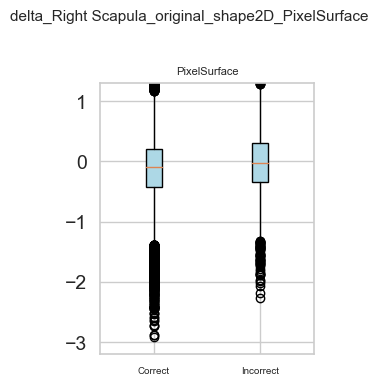


Feature: delta_Right Scapula_original_shape2D_MeshSurface


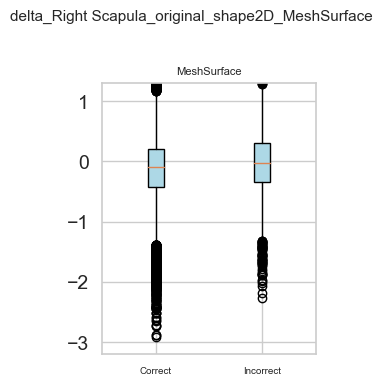


Feature: delta_Heart_original_shape2D_PixelSurface


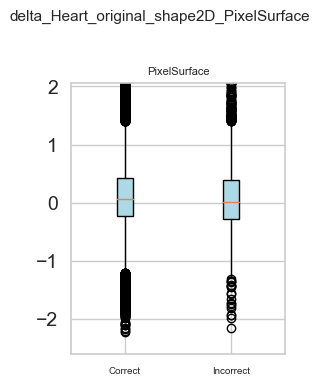


Feature: delta_Spine_original_shape2D_MeshSurface


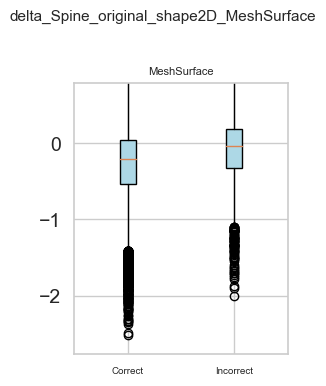


Feature: delta_Spine_original_shape2D_PixelSurface


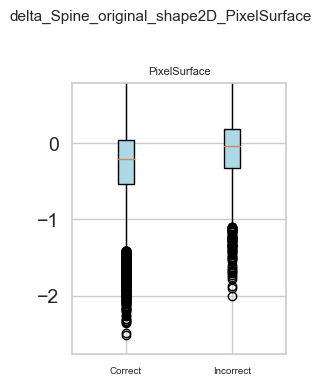


Feature: delta_Heart_original_shape2D_MeshSurface


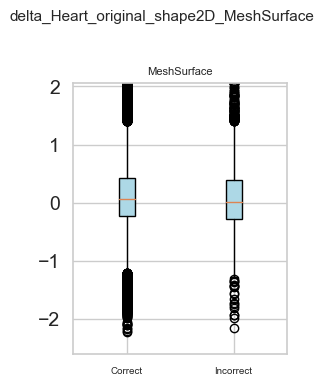


Feature: delta_Left Hilus Pulmonis_original_shape2D_PixelSurface


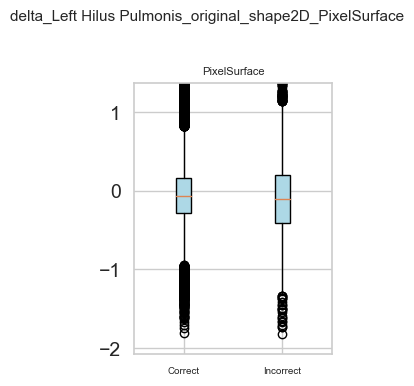


Feature: delta_Left Hilus Pulmonis_original_firstorder_Minimum


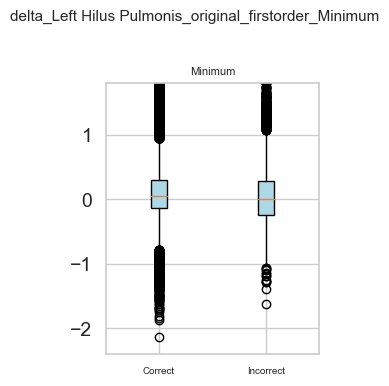


Feature: delta_Left Hilus Pulmonis_original_shape2D_MeshSurface


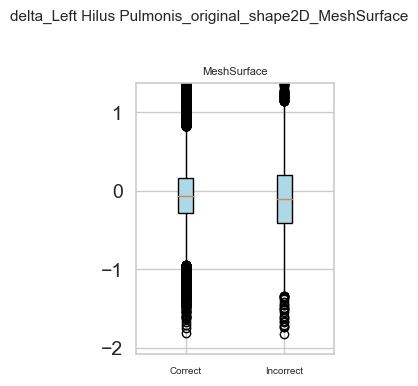


Feature: delta_Left Scapula_original_shape2D_MeshSurface


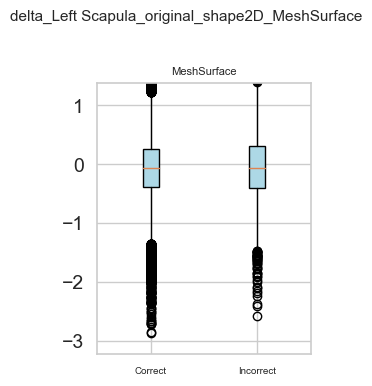


Feature: delta_Left Scapula_original_shape2D_PixelSurface


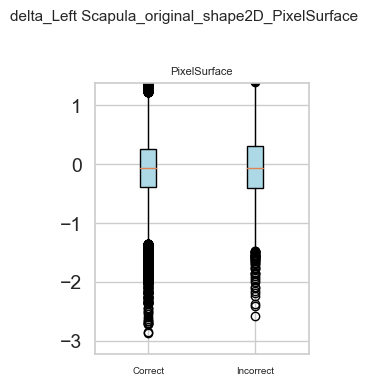


Feature: delta_Left Lung_original_shape2D_PixelSurface


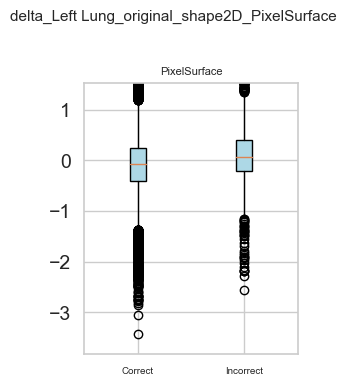


Feature: delta_Left Lung_original_shape2D_MeshSurface


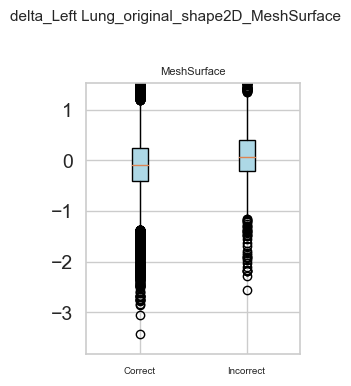


Feature: delta_Left Hilus Pulmonis_original_firstorder_Maximum


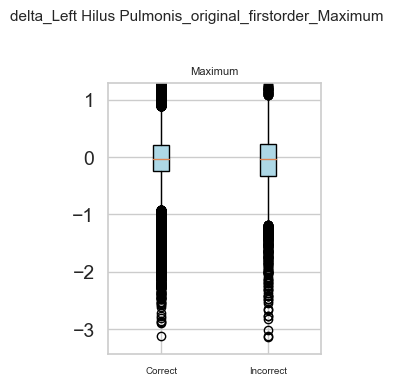


Feature: delta_Right Hilus Pulmonis_original_firstorder_Range


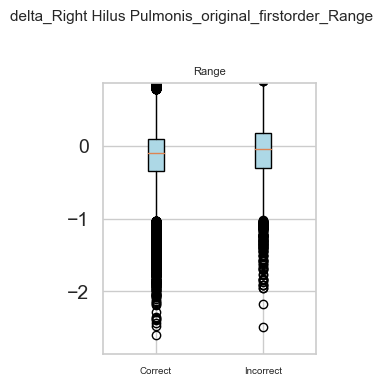


Feature: delta_Mediastinum_original_shape2D_PixelSurface


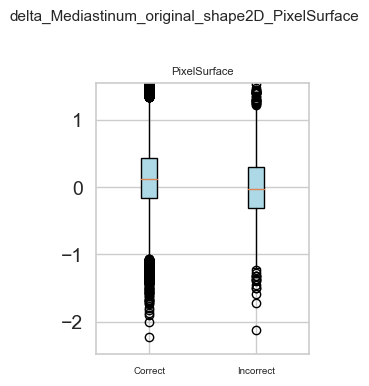


Feature: delta_Mediastinum_original_shape2D_MeshSurface


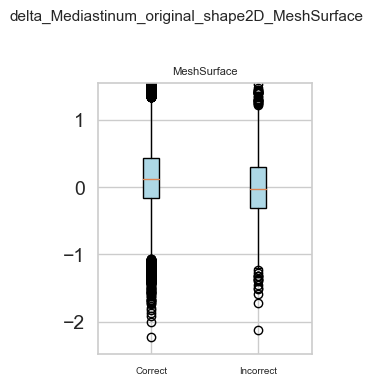


Feature: delta_Right Hilus Pulmonis_original_firstorder_Minimum


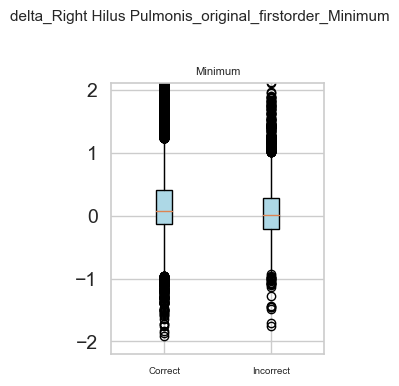


Feature: delta_Weasand_original_shape2D_MeshSurface


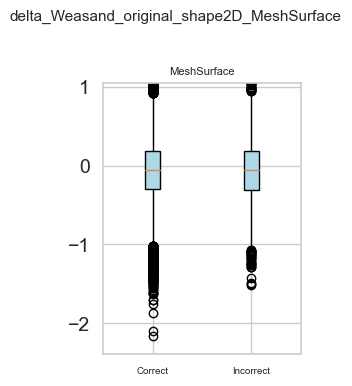

In [138]:
# Plot the top features (not grouped by category)
for feature in top_features['feature']:
    print(f"\nFeature: {feature}")
    plot_category(cf16_merged_data, feature, [feature])

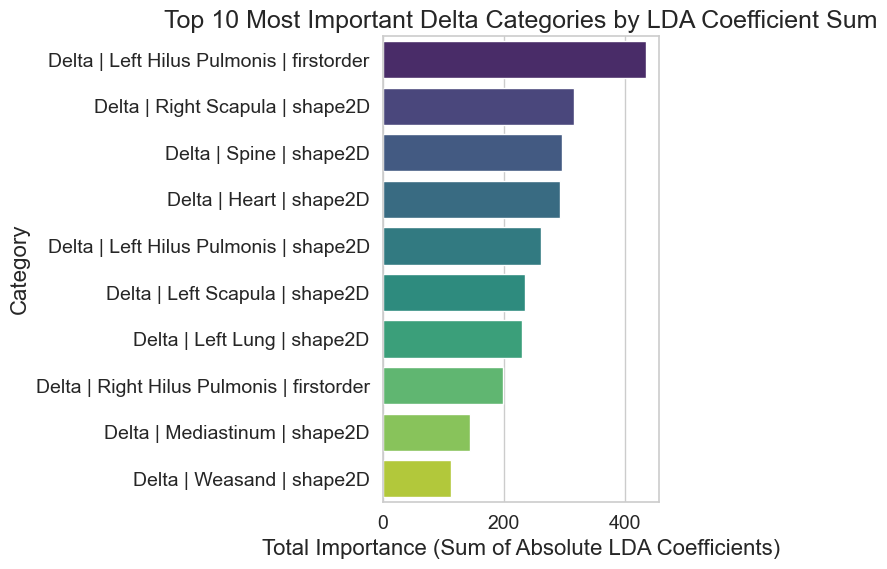

In [136]:
plt.rcParams.update({
    'font.size': 17,
    'axes.linewidth': 1.2,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
})

top_categories = (
    feature_importance_df
    .groupby('category', as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
    .head(10)
)

# Now plot top categories
plt.figure(figsize=(7, 6))
sns.barplot(
    data=top_categories,
    x='importance',
    y='category',
    palette='viridis'
)
plt.title('Top 10 Most Important Delta Categories by LDA Coefficient Sum')
plt.xlabel('Total Importance (Sum of Absolute LDA Coefficients)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes cf16_merged_data is already loaded
delta_cols = [c for c in cf16_merged_data.columns if c.startswith("delta_")]

# Compute L2 norm of the full ΔA vector per sample
cf16_merged_data["delta_norm"] = np.linalg.norm(cf16_merged_data[delta_cols].values, axis=1)

# Split by correctness and plot
correct   = cf16_merged_data.loc[cf16_merged_data["correct"] == 1, "delta_norm"]
incorrect = cf16_merged_data.loc[cf16_merged_data["correct"] == 0, "delta_norm"]

print(f"Correct   mean norm: {correct.mean():.4f}")
print(f"Incorrect mean norm: {incorrect.mean():.4f}")

Correct   mean norm: 43.5043
Incorrect mean norm: 42.5018
